In [1]:
from pathlib import Path
import json
import random


In [ ]:
from pathlib import Path
import json
import random

import matplotlib.pyplot as plt
from skimage.io import imread

DATA_DIR = Path("/net/projects2/promega/project_data/amanda_test")
#ALL_DATA = DATA_DIR / "identifiers/all_data.json"
ALL_DATA = DATA_DIR / "images" / "image_map_resized_512x384_predicted_overlay_ar_meanfill.json"

def resolve_path(p):
    """Return Path or None. Treat strings as paths; accept absolute or relative."""
    if not p:
        return None
    p = Path(p)
    return p if p.is_absolute() else (DATA_DIR / p)

def get_cm_triplet(rec, mode):  # mode in {"std", "ar"}
    """
    Returns (filled_img, source_img, source_mask) for clipped_meanfill.{mode}
    using *_abs fields.
    """
    cm = rec.get("images", {}).get("clipped_meanfill", {}).get(mode, {})
    filled = resolve_path(cm.get("cm_image_abs"))
    src_img = resolve_path(cm.get("cm_source_image_abs"))
    src_msk = resolve_path(cm.get("cm_source_mask_abs"))
    return filled, src_img, src_msk

def record_has_cm_files(rec):
    paths = []
    for mode in ("std", "ar"):
        paths.extend(get_cm_triplet(rec, mode))
    return all(p is not None and p.exists() for p in paths)

def safe_imshow(ax, path, title):
    ax.set_title(title, fontsize=22)
    ax.axis("off")
    if path is None:
        ax.text(0.5, 0.5, "None", ha="center", va="center", fontsize=22)
        return
    if not path.exists():
        ax.text(0.5, 0.5, f"Missing:\n{path}", ha="center", va="center", fontsize=22)
        return
    ax.imshow(imread(str(path)))

def show_cm_six(rec_id, rec):
    std_filled, std_src_img, std_src_msk = get_cm_triplet(rec, "std")
    ar_filled,  ar_src_img,  ar_src_msk  = get_cm_triplet(rec, "ar")

    fig, axes = plt.subplots(2, 3, figsize=(11, 7))
    fig.suptitle(rec_id)

    panels = [
        ("cm_image_abs", std_filled),
        ("cm_source_image_abs", std_src_img),
        ("cm_source_mask_abs", std_src_msk),
        ("cm_image_abs", ar_filled),
        ("cm_source_image_abs", ar_src_img),
        ("cm_source_mask_abs", ar_src_msk),
    ]

    for ax, (title, path) in zip(axes.ravel(), panels):
        safe_imshow(ax, path, title)

    # optional: print paths for debugging
    print(f"\n{rec_id}")
    for title, path in panels:
        print(f"  {title}: {path}")

    plt.tight_layout()
    plt.show()

# ----------------------------
# load all_data.json
# ----------------------------
with ALL_DATA.open("r") as f:
    all_data = json.load(f)

# ----------------------------
# random 5 examples where all 6 exist
# ----------------------------
keys = list(all_data.keys())
random.shuffle(keys)

eligible = []
for k in keys:
    rec = all_data[k]
    if record_has_cm_files(rec):
        eligible.append(k)
    if len(eligible) >= 10:
        break

print(f"Found {len(eligible)} eligible records (showing up to 5).")
for k in eligible:
    show_cm_six(k, all_data[k])


Found 0 eligible records (showing up to 5).


In [ ]:
import tifffile
from pathlib import Path

p = Path("/net/projects2/promega/data_reorg/data/images/raw_images/Ba2 96_2 Dy28 E12(stitched) Z2.tif")
with tifffile.TiffFile(str(p)) as tf:
    page = tf.pages[0]
    print("shape:", page.shape)
    print("XResolution:", page.tags.get("XResolution"))
    print("YResolution:", page.tags.get("YResolution"))
    print("ResolutionUnit:", page.tags.get("ResolutionUnit"))
    desc = page.tags.get("ImageDescription")
    print("Has ImageDescription:", desc is not None)
    if desc:
        print(str(desc.value)[:800])


: 

In [8]:
ar_sizes = [
    (
        r["images"]["aspect_ratio"]["ar_scaled_w"],
        r["images"]["aspect_ratio"]["ar_scaled_h"],
        r["metadata"]["verification"]["classification_verification"]
    )
    for r in data.values()
    if r["images"].get("aspect_ratio")
]

ws, hs, labels = zip(*ar_sizes)

plt.figure(figsize=(5,5))
plt.scatter(ws, hs, s=5, alpha=0.3)
plt.xlabel("scaled width (px)")
plt.ylabel("scaled height (px)")
plt.axvline(575, ls="--", c="r")
plt.axhline(575, ls="--", c="r")



TypeError: string indices must be integers, not 'str'

In [12]:
import json
import numpy as np
import pandas as pd
from pathlib import Path
from PIL import Image
from tqdm import tqdm
import matplotlib.pyplot as plt

DATA_DIR = Path("/net/projects2/promega/project_data/amanda_test")
ALL_DATA_JSON = DATA_DIR / "identifiers" / "all_data.json"

# If your AR masks live elsewhere, adjust these two:
AR_MASK_DIR_DEFAULT_1 = DATA_DIR / "masks" / "resized_575_square"
AR_MASK_DIR_DEFAULT_2 = DATA_DIR / "images" / "resized_575_square"  # fallback (in case you saved masks w/ images)

with open(ALL_DATA_JSON, "r") as f:
    data = json.load(f)

def load_mask_as_bool(mask_path: Path) -> np.ndarray:
    # Treat any nonzero pixel as mask
    arr = np.array(Image.open(mask_path))
    if arr.ndim == 3:
        # if RGB/RGBA, collapse
        arr = arr[..., 0]
    return arr > 0

rows = []
missing_ar = 0
missing_mask_file = 0
bad_day = 0

for rid, r in tqdm(data.items(), total=len(data), desc="AR mask area"):
    day_num = r.get("day", {}).get("number", None)
    if day_num is None:
        bad_day += 1
        continue

    # edge_frac = r.get("images", {}).get("edge_fraction", 0.0)
    # if edge_frac > 0.5:
    #     continue

    cm_ar = r.get("images", {}).get("clipped_meanfill", {}).get("ar", {})
    mask_path = cm_ar.get("cm_source_mask_abs", None)
    um_per_px = r.get("images", {}).get("aspect_ratio", {}).get("ar_target_um_per_px", None)

    if not mask_path or um_per_px is None:
        missing_ar += 1
        continue

    mask_path = Path(mask_path)
    if not mask_path.exists():
        missing_mask_file += 1
        continue

    m = load_mask_as_bool(mask_path)
    mask_px = int(m.sum())
    area_um2 = mask_px * (float(um_per_px) ** 2)

    rows.append({
        "record_id": rid,
        "day": float(day_num),
        "mask_px": mask_px,
        "um_per_px": float(um_per_px),
        "area_um2": area_um2,
        "edge_fraction": edge_frac,
        "class_verif": r.get("metadata", {}).get("verification", {}).get("classification_verification", None),
    })


df = pd.DataFrame(rows)

print("records:", len(data))
print("kept:", len(df))
print("missing_ar:", missing_ar)
print("missing_mask_file:", missing_mask_file)
print("bad_day:", bad_day)

# mean area per day (sorted)
by_day = (
    df.groupby("day", as_index=False)
      .agg(n=("area_um2", "size"),
           mean_area_um2=("area_um2", "mean"),
           std_area_um2=("area_um2", "std"))
      .sort_values("day")
)

by_day

plt.figure(figsize=(6,4))
plt.errorbar(by_day["day"], by_day["mean_area_um2"], yerr=by_day["std_area_um2"], fmt="-o", capsize=3)
plt.xlabel("Day")
plt.ylabel("Mean AR mask area (µm²)")
plt.title("AR-mask area by day")
plt.tight_layout()
plt.show()


AR mask area: 100%|██████████| 5168/5168 [00:00<00:00, 437575.21it/s]


records: 5168
kept: 0
missing_ar: 5168
missing_mask_file: 0
bad_day: 0


KeyError: 'day'

In [4]:
import numpy as np
import matplotlib.pyplot as plt

import matplotlib.cm as cm
df["batch"] = df["record_id"].map(
    lambda k: data[k]["plate"]["batch"]
)
by_day_batch = (
    df.groupby(["batch", "day"], as_index=False)
      .agg(
          n=("area_um2", "size"),
          mean_area_um2=("area_um2", "mean"),
          std_area_um2=("area_um2", "std"),
      )
      .sort_values(["batch", "day"])
)

# Compute stats
stats = (
    df.groupby(["batch", "day"])
      .agg(
          median_area_um2=("area_um2", "median"),
          mean_area_um2=("area_um2", "mean"),
          std_area_um2=("area_um2", "std"),
          n=("area_um2", "size"),
      )
      .reset_index()
)

stats["sem_area_um2"] = stats["std_area_um2"] / np.sqrt(stats["n"])

# ---- magma color mapping per batch ----
batches = sorted(stats["batch"].unique())
cmap = cm.get_cmap("viridis", len(batches))
batch_colors = {b: cmap(i) for i, b in enumerate(batches)}

# Plot
plt.figure(figsize=(7,5))

for batch, sub in stats.groupby("batch"):
    sub = sub.sort_values("day")
    color = batch_colors[batch]

    plt.plot(
        sub["day"],
        sub["median_area_um2"],
        linewidth=2.5,
        color=color,
        label=batch
    )

    plt.fill_between(
        sub["day"],
        sub["median_area_um2"] - sub["sem_area_um2"],
        sub["median_area_um2"] + sub["sem_area_um2"],
        alpha=0.15,
        color=color
    )

plt.xlabel("Day", fontsize=22)
plt.ylabel("Median area (µm²)", fontsize=22)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.legend(title="Batch", frameon=False)
plt.title("Mean area per day", fontsize=22)
plt.grid(False)
plt.tight_layout()
plt.show()

NameError: name 'df' is not defined

In [7]:
import json
import numpy as np
import pandas as pd
from pathlib import Path
from PIL import Image
from tqdm import tqdm
import matplotlib.pyplot as plt

# ----------------------------
# Paths
# ----------------------------

DATA_DIR = Path("/net/projects2/promega/project_data/amanda_test")
#ALL_DATA_JSON = DATA_DIR / "identifiers" / "all_data.json"
ALL_DATA_JSON = DATA_DIR / "images" / "image_map_resized_512x384_predicted_overlay_ar_meanfill.json"
# ----------------------------
# Load
# ----------------------------
with open(ALL_DATA_JSON, "r") as f:
    data = json.load(f)

def load_mask_as_bool(mask_path: Path) -> np.ndarray:
    arr = np.array(Image.open(mask_path))
    if arr.ndim == 3:
        arr = arr[..., 0]
    return arr >= 128  # robust for binary masks saved as 0/255

rows = []
missing_mask = 0
missing_scale = 0

for rid, r in tqdm(data.items(), total=len(data), desc="Build area table"):
    # stable identifiers
    organoid_id = r.get("organoid_id", None)
    day = r.get("day", {}).get("number", None)
    batch = r.get("plate", {}).get("batch", None)
    well = r.get("plate", {}).get("well", None)

    if organoid_id is None or day is None or batch is None:
        continue

    # exclude splits/stitched for now (cleanest flag in your schema)
    class_ver = r.get("metadata", {}).get("verification", {}).get("classification_verification", None)

    KEEP = {"NoSplitNoStitched", "NoSplitStitched"}
    if class_ver not in KEEP:
        continue


    edge_frac = r.get("images", {}).get("edge_fraction", None)
    if edge_frac is not None and edge_frac > 0.05:
        continue

    # AR mask source (binary mask)
    cm_ar = r.get("images", {}).get("clipped_meanfill", {}).get("ar", {})
    mask_path = cm_ar.get("cm_source_mask_abs", None)

    # physical scale used for AR products
    um_per_px = r.get("images", {}).get("aspect_ratio", {}).get("ar_target_um_per_px", None)

    if um_per_px is None:
        missing_scale += 1
        continue
    if not mask_path:
        missing_mask += 1
        continue

    mask_path = Path(mask_path)
    if not mask_path.exists():
        missing_mask += 1
        continue

    m = load_mask_as_bool(mask_path)
    mask_px = int(m.sum())
    area_um2 = mask_px * (float(um_per_px) ** 2)

    edge_frac = r.get("images", {}).get("edge_fraction", None)

    rows.append({
        "record_key": rid,                 # unique key in all_data.json
        "organoid_id": organoid_id,        # stable across days
        "batch": batch,
        "well": well,
        "day": float(day),
        "mask_px": mask_px,
        "um_per_px": float(um_per_px),
        "area_um2": area_um2,
        "edge_fraction": edge_frac,
        "classification_verification": class_ver,
    })

df_area = pd.DataFrame(rows)

print("Total records in JSON:", len(data))
print("Kept rows (NoSplitNoStitched):", len(df_area))
print("Missing mask:", missing_mask)
print("Missing scale:", missing_scale)

# ----------------------------
# Per-organoid delta area + rate
# ----------------------------
df_area = df_area.sort_values(["organoid_id", "day"]).copy()

df_area["delta_area_um2"] = df_area.groupby("organoid_id")["area_um2"].diff()
df_area["delta_day"] = df_area.groupby("organoid_id")["day"].diff()
df_area["delta_area_um2_per_day"] = df_area["delta_area_um2"] / df_area["delta_day"]

# (optional) drop first timepoint per organoid (no delta)
df_delta = df_area.dropna(subset=["delta_area_um2_per_day"]).copy()

# ----------------------------
# Aggregate by batch + day (like before)
# Here "day" is the RIGHT endpoint of the interval (e.g., delta 20.5->24 is plotted at day=24)
# ----------------------------
by_day_batch_delta = (
    df_delta.groupby(["batch", "day"], as_index=False)
            .agg(
                n=("delta_area_um2_per_day", "size"),
                mean_rate=("delta_area_um2_per_day", "mean"),
                std_rate=("delta_area_um2_per_day", "std"),
                median_rate=("delta_area_um2_per_day", "median"),
            )
            .sort_values(["batch", "day"])
)

by_day_batch_delta["sem_rate"] = by_day_batch_delta["std_rate"] / np.sqrt(by_day_batch_delta["n"].clip(lower=1))

# ----------------------------
# Plot: mean delta-area rate with SEM shading
import matplotlib.cm as cm

batches = sorted(by_day_batch_delta["batch"].unique())
cmap = cm.get_cmap("viridis", len(batches))
batch_colors = {b: cmap(i) for i, b in enumerate(batches)}

# ----------------------------
plt.figure(figsize=(7, 5))

for batch, sub in by_day_batch_delta.groupby("batch"):
    sub = sub.sort_values("day")

    color = batch_colors[batch]
    plt.plot(sub["day"], sub["mean_rate"],
            marker="o", linewidth=2, label=batch, color=color)
    plt.fill_between(
        sub["day"],
        sub["mean_rate"] - sub["sem_rate"],
        sub["mean_rate"] + sub["sem_rate"],
        alpha=0.2,
        color=color
    )


plt.axhline(0, linewidth=1)
plt.xlabel("Day (interval endpoint)", fontsize=22)
plt.ylabel("µm²/day", fontsize=22)
plt.title("Mean growth rate by batch (no splits)", fontsize=22)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.legend(title="Batch", frameon=False, fontsize=8)
plt.tight_layout()
plt.show()

# ----------------------------
# If you prefer median rate (robust), plot that too (no SEM unless you bootstrap)
# ----------------------------
plt.figure(figsize=(7, 5))

for batch, sub in by_day_batch_delta.groupby("batch"):
    sub = sub.sort_values("day")

    color = batch_colors[batch]
    plt.plot(sub["day"], sub["median_rate"],
            marker="o", linewidth=2, label=batch, color=color)


plt.axhline(0, linewidth=1)
plt.xlabel("Day (interval endpoint)", fontsize=22)
plt.ylabel("µm²/day", fontsize=22)
plt.title("Median growth rate by batch (no splits)", fontsize=22)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.legend(title="Batch", frameon=False, fontsize=8)
plt.tight_layout()
plt.show()



Build area table:   0%|          | 0/6 [00:00<?, ?it/s]


AttributeError: 'str' object has no attribute 'get'

Build area table: 100%|██████████| 5168/5168 [00:23<00:00, 221.68it/s]


Total entries: 5168
Rows kept: 5078
Missing mask: 0
Missing scale: 0


,record_key,organoid_id,batch,well,day,mask_px,um_per_px,area_um2,edge_fraction,classification_verification
0,BA1 96_1 Dy03 A1,BA1_96_1_Dy03_A1_nosplit_nostitch,BA1 96_1,A1,3.0,2780,9.0,225180.0,None,NoSplitNoStitched
1,BA1 96_1 Dy03 A10,BA1_96_1_Dy03_A10_nosplit_nostitch,BA1 96_1,A10,3.0,2874,9.0,232794.0,None,NoSplitNoStitched
2,BA1 96_1 Dy03 A11,BA1_96_1_Dy03_A11_nosplit_nostitch,BA1 96_1,A11,3.0,2734,9.0,221454.0,None,NoSplitNoStitched
3,BA1 96_1 Dy03 A12,BA1_96_1_Dy03_A12_nosplit_nostitch,BA1 96_1,A12,3.0,2878,9.0,233118.0,None,NoSplitNoStitched
4,BA1 96_1 Dy03 A2,BA1_96_1_Dy03_A2_nosplit_nostitch,BA1 96_1,A2,3.0,2926,9.0,237006.0,None,NoSplitNoStitched


/tmp/ipykernel_2000431/3820257282.py:112: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = mpl_cm.get_cmap("viridis", len(batches))


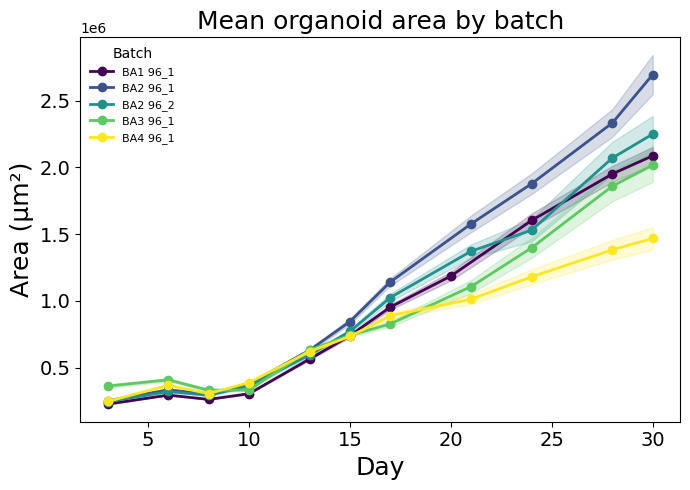

Rows with growth estimates: 0


,record_key,organoid_id,batch,well,day,mask_px,um_per_px,area_um2,edge_fraction,classification_verification,delta_area_um2,delta_day,delta_area_um2_per_day


ValueError: df_delta is empty. No growth can be computed.

In [14]:
import json
import numpy as np
import pandas as pd
from pathlib import Path
from PIL import Image
from tqdm import tqdm
import matplotlib.pyplot as plt
import matplotlib.cm as mpl_cm

DATA_DIR = Path("/net/projects2/promega/project_data/amanda_test")
MAP_JSON = DATA_DIR / "images" / "image_map_resized_512x384_predicted_overlay_ar_meanfill.json"

with open(MAP_JSON, "r") as f:
    data = json.load(f)

entries = data["entries"]

def load_mask_as_bool(mask_path: Path) -> np.ndarray:
    arr = np.array(Image.open(mask_path))
    if arr.ndim == 3:
        arr = arr[..., 0]
    return arr >= 128

rows = []
missing_mask = 0
missing_scale = 0

for rid, r in tqdm(entries.items(), total=len(entries), desc="Build area table"):
    organoid_id = r.get("verification", {}).get("main_id", rid)
    day_id = r.get("dayID", None)
    batch = r.get("BA", None)
    well = r.get("wellID", None)

    if organoid_id is None or day_id is None or batch is None:
        continue

    try:
        day = float(str(day_id).replace("Dy", ""))
    except Exception:
        continue

    class_ver = r.get("verification", {}).get("classification_verification", None)
    KEEP = {"NoSplitNoStitched", "NoSplitStitched"}
    if class_ver not in KEEP:
        continue

    edge_frac = r.get("edge_fraction", None)
    if edge_frac is not None and edge_frac > 0.05:
        continue

    cm_info = r.get("clipped_meanfill_auto", {})
    mask_path = cm_info.get("cm_source_mask_abs", None)

    ar = r.get("aspect_ratio", {})
    um_per_px = ar.get("ar_target_um_per_px", None)

    if um_per_px is None:
        missing_scale += 1
        continue
    if not mask_path:
        missing_mask += 1
        continue

    mask_path = Path(mask_path)
    if not mask_path.exists():
        missing_mask += 1
        continue

    m = load_mask_as_bool(mask_path)
    mask_px = int(m.sum())
    area_um2 = mask_px * (float(um_per_px) ** 2)

    rows.append({
        "record_key": rid,
        "organoid_id": organoid_id,
        "batch": batch,
        "well": well,
        "day": day,
        "mask_px": mask_px,
        "um_per_px": float(um_per_px),
        "area_um2": area_um2,
        "edge_fraction": edge_frac,
        "classification_verification": class_ver,
    })

df_area = pd.DataFrame(rows)

print("Total entries:", len(entries))
print("Rows kept:", len(df_area))
print("Missing mask:", missing_mask)
print("Missing scale:", missing_scale)
display(df_area.head())

if df_area.empty:
    raise ValueError("df_area is empty after filtering.")

# Plot 1: raw area
by_day_batch_area = (
    df_area.groupby(["batch", "day"], as_index=False)
           .agg(
               n=("area_um2", "size"),
               mean_area=("area_um2", "mean"),
               std_area=("area_um2", "std"),
               median_area=("area_um2", "median"),
           )
           .sort_values(["batch", "day"])
)

by_day_batch_area["sem_area"] = by_day_batch_area["std_area"] / np.sqrt(by_day_batch_area["n"].clip(lower=1))

batches = sorted(by_day_batch_area["batch"].unique())
cmap = mpl_cm.get_cmap("viridis", len(batches))
batch_colors = {b: cmap(i) for i, b in enumerate(batches)}

plt.figure(figsize=(7, 5))
for batch, sub in by_day_batch_area.groupby("batch"):
    sub = sub.sort_values("day")
    color = batch_colors[batch]
    plt.plot(sub["day"], sub["mean_area"], marker="o", linewidth=2, color=color, label=batch)
    plt.fill_between(
        sub["day"],
        sub["mean_area"] - sub["sem_area"],
        sub["mean_area"] + sub["sem_area"],
        alpha=0.2,
        color=color
    )

plt.xlabel("Day", fontsize=18)
plt.ylabel("Area (µm²)", fontsize=18)
plt.title("Mean organoid area by batch", fontsize=18)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.legend(title="Batch", frameon=False, fontsize=8)
plt.tight_layout()
plt.show()

# Compute growth
df_area = df_area.sort_values(["organoid_id", "day"]).copy()
df_area["delta_area_um2"] = df_area.groupby("organoid_id")["area_um2"].diff()
df_area["delta_day"] = df_area.groupby("organoid_id")["day"].diff()
df_area["delta_area_um2_per_day"] = df_area["delta_area_um2"] / df_area["delta_day"]

df_delta = df_area.dropna(subset=["delta_area_um2_per_day"]).copy()

print("Rows with growth estimates:", len(df_delta))
display(df_delta.head())

if df_delta.empty:
    raise ValueError("df_delta is empty. No growth can be computed.")

# Plot 2: growth rate
by_day_batch_delta = (
    df_delta.groupby(["batch", "day"], as_index=False)
            .agg(
                n=("delta_area_um2_per_day", "size"),
                mean_rate=("delta_area_um2_per_day", "mean"),
                std_rate=("delta_area_um2_per_day", "std"),
                median_rate=("delta_area_um2_per_day", "median"),
            )
            .sort_values(["batch", "day"])
)

by_day_batch_delta["sem_rate"] = by_day_batch_delta["std_rate"] / np.sqrt(by_day_batch_delta["n"].clip(lower=1))

plt.figure(figsize=(7, 5))
for batch, sub in by_day_batch_delta.groupby("batch"):
    sub = sub.sort_values("day")
    color = batch_colors.get(batch, None)
    plt.plot(sub["day"], sub["mean_rate"], marker="o", linewidth=2, color=color, label=batch)
    plt.fill_between(
        sub["day"],
        sub["mean_rate"] - sub["sem_rate"],
        sub["mean_rate"] + sub["sem_rate"],
        alpha=0.2,
        color=color
    )

plt.axhline(0, linewidth=1)
plt.xlabel("Day (interval endpoint)", fontsize=18)
plt.ylabel("Growth rate (µm²/day)", fontsize=18)
plt.title("Mean organoid growth rate by batch", fontsize=18)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.legend(title="Batch", frameon=False, fontsize=8)
plt.tight_layout()
plt.show()

In [ ]:
import json
import numpy as np
import pandas as pd
from pathlib import Path
from PIL import Image
from tqdm import tqdm
import matplotlib.pyplot as plt

# ----------------------------
# Paths
# ----------------------------

DATA_DIR = Path("/net/projects2/promega/project_data/amanda_test")
#ALL_DATA_JSON = DATA_DIR / "identifiers" / "all_data.json"
ALL_DATA_JSON = DATA_DIR / "images" / "image_map_resized_512x384_predicted_overlay_ar_meanfill.json"
# ----------------------------
# Load
# ----------------------------
with open(ALL_DATA_JSON, "r") as f:
    data = json.load(f)

def load_mask_as_bool(mask_path: Path) -> np.ndarray:
    arr = np.array(Image.open(mask_path))
    if arr.ndim == 3:
        arr = arr[..., 0]
    return arr >= 128  # robust for binary masks saved as 0/255

rows = []
missing_mask = 0
missing_scale = 0

for rid, r in tqdm(data.items(), total=len(data), desc="Build area table"):
    # stable identifiers
    organoid_id = r.get("organoid_id", None)
    day = r.get("day", {}).get("number", None)
    batch = r.get("plate", {}).get("batch", None)
    well = r.get("plate", {}).get("well", None)

    if organoid_id is None or day is None or batch is None:
        continue

    # exclude splits/stitched for now (cleanest flag in your schema)
    class_ver = r.get("metadata", {}).get("verification", {}).get("classification_verification", None)

    KEEP = {"NoSplitNoStitched", "NoSplitStitched"}
    if class_ver not in KEEP:
        continue


    edge_frac = r.get("images", {}).get("edge_fraction", None)
    if edge_frac is not None and edge_frac > 0.05:
        continue

    # AR mask source (binary mask)
    cm_ar = r.get("images", {}).get("clipped_meanfill", {}).get("ar", {})
    mask_path = cm_ar.get("cm_source_mask_abs", None)

    # physical scale used for AR products
    um_per_px = r.get("images", {}).get("aspect_ratio", {}).get("ar_target_um_per_px", None)

    if um_per_px is None:
        missing_scale += 1
        continue
    if not mask_path:
        missing_mask += 1
        continue

    mask_path = Path(mask_path)
    if not mask_path.exists():
        missing_mask += 1
        continue

    m = load_mask_as_bool(mask_path)
    mask_px = int(m.sum())
    area_um2 = mask_px * (float(um_per_px) ** 2)

    edge_frac = r.get("images", {}).get("edge_fraction", None)

    rows.append({
        "record_key": rid,                 # unique key in all_data.json
        "organoid_id": organoid_id,        # stable across days
        "batch": batch,
        "well": well,
        "day": float(day),
        "mask_px": mask_px,
        "um_per_px": float(um_per_px),
        "area_um2": area_um2,
        "edge_fraction": edge_frac,
        "classification_verification": class_ver,
    })

df_area = pd.DataFrame(rows)

print("Total records in JSON:", len(data))
print("Kept rows (NoSplitNoStitched):", len(df_area))
print("Missing mask:", missing_mask)
print("Missing scale:", missing_scale)

# ----------------------------
# Per-organoid delta area + rate
# ----------------------------
df_area = df_area.sort_values(["organoid_id", "day"]).copy()

df_area["delta_area_um2"] = df_area.groupby("organoid_id")["area_um2"].diff()
df_area["delta_day"] = df_area.groupby("organoid_id")["day"].diff()
df_area["delta_area_um2_per_day"] = df_area["delta_area_um2"] / df_area["delta_day"]

# (optional) drop first timepoint per organoid (no delta)
df_delta = df_area.dropna(subset=["delta_area_um2_per_day"]).copy()

# ----------------------------
# Aggregate by batch + day (like before)
# Here "day" is the RIGHT endpoint of the interval (e.g., delta 20.5->24 is plotted at day=24)
# ----------------------------
by_day_batch_delta = (
    df_delta.groupby(["batch", "day"], as_index=False)
            .agg(
                n=("delta_area_um2_per_day", "size"),
                mean_rate=("delta_area_um2_per_day", "mean"),
                std_rate=("delta_area_um2_per_day", "std"),
                median_rate=("delta_area_um2_per_day", "median"),
            )
            .sort_values(["batch", "day"])
)

by_day_batch_delta["sem_rate"] = by_day_batch_delta["std_rate"] / np.sqrt(by_day_batch_delta["n"].clip(lower=1))

# ----------------------------
# Plot: mean delta-area rate with SEM shading
import matplotlib.cm as cm

batches = sorted(by_day_batch_delta["batch"].unique())
cmap = cm.get_cmap("viridis", len(batches))
batch_colors = {b: cmap(i) for i, b in enumerate(batches)}

# ----------------------------
plt.figure(figsize=(7, 5))

for batch, sub in by_day_batch_delta.groupby("batch"):
    sub = sub.sort_values("day")

    color = batch_colors[batch]
    plt.plot(sub["day"], sub["mean_rate"],
            marker="o", linewidth=2, label=batch, color=color)
    plt.fill_between(
        sub["day"],
        sub["mean_rate"] - sub["sem_rate"],
        sub["mean_rate"] + sub["sem_rate"],
        alpha=0.2,
        color=color
    )


plt.axhline(0, linewidth=1)
plt.xlabel("Day (interval endpoint)", fontsize=22)
plt.ylabel("µm²/day", fontsize=22)
plt.title("Mean growth rate by batch (no splits)", fontsize=22)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.legend(title="Batch", frameon=False, fontsize=8)
plt.tight_layout()
plt.show()

# ----------------------------
# If you prefer median rate (robust), plot that too (no SEM unless you bootstrap)
# ----------------------------
plt.figure(figsize=(7, 5))

for batch, sub in by_day_batch_delta.groupby("batch"):
    sub = sub.sort_values("day")

    color = batch_colors[batch]
    plt.plot(sub["day"], sub["median_rate"],
            marker="o", linewidth=2, label=batch, color=color)


plt.axhline(0, linewidth=1)
plt.xlabel("Day (interval endpoint)", fontsize=22)
plt.ylabel("µm²/day", fontsize=22)
plt.title("Median growth rate by batch (no splits)", fontsize=22)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.legend(title="Batch", frameon=False, fontsize=8)
plt.tight_layout()
plt.show()



Build area table:   0%|          | 0/6 [00:00<?, ?it/s]


AttributeError: 'str' object has no attribute 'get'

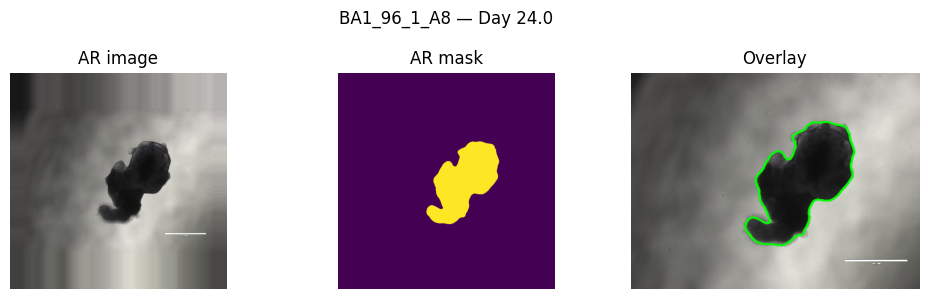

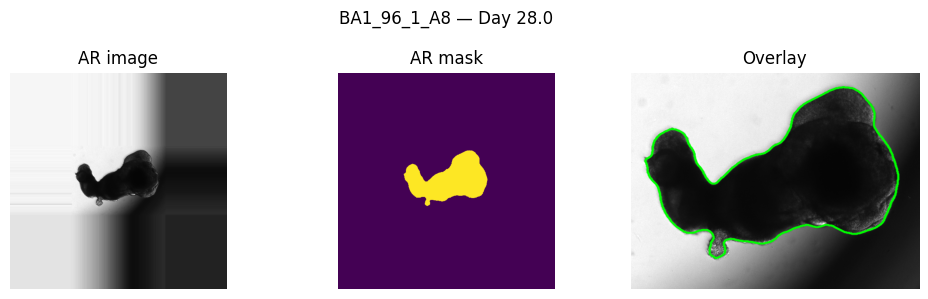

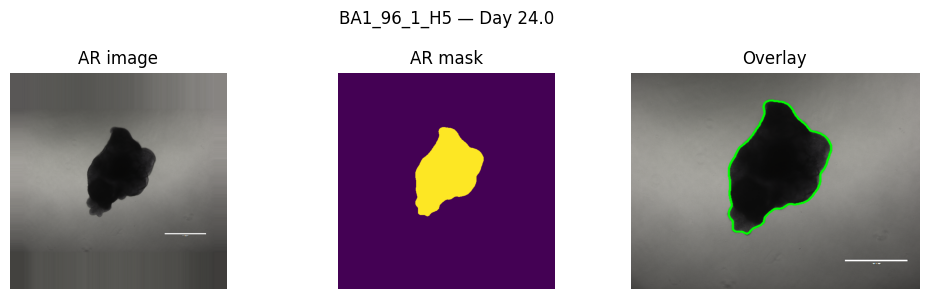

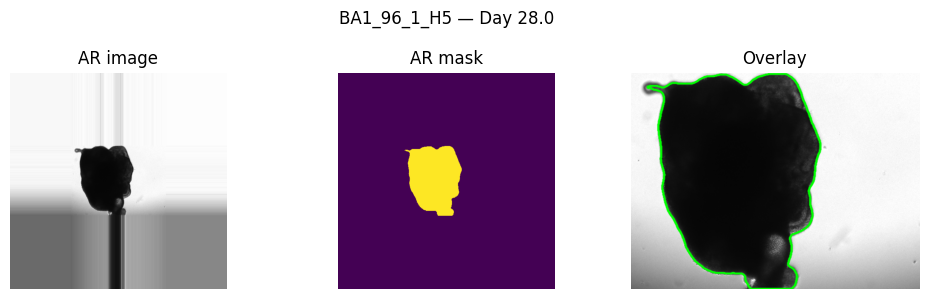

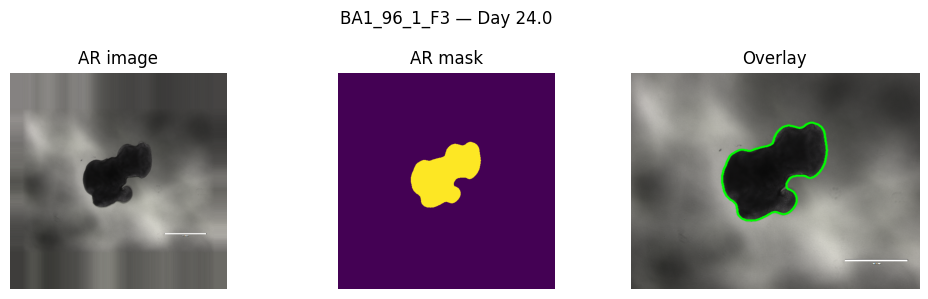

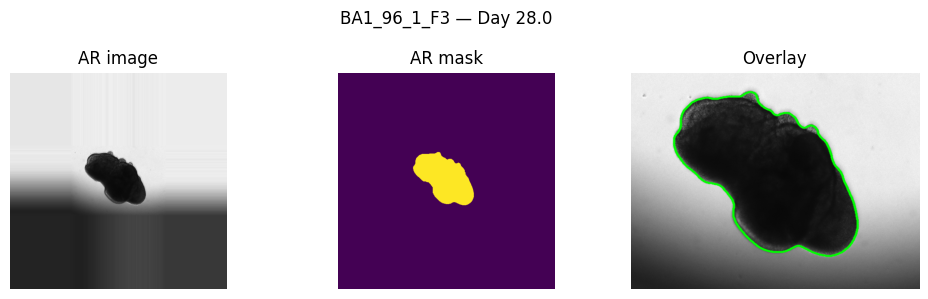

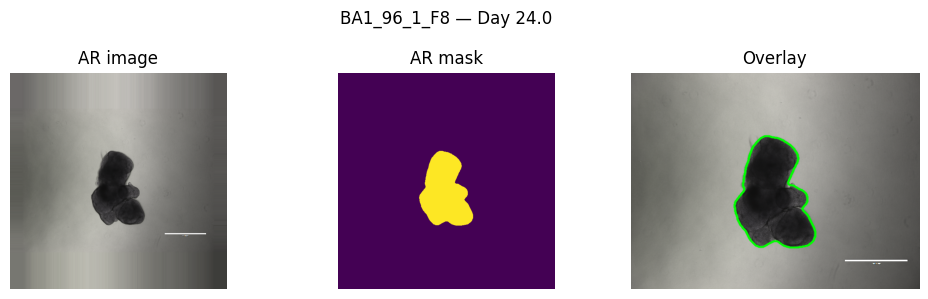

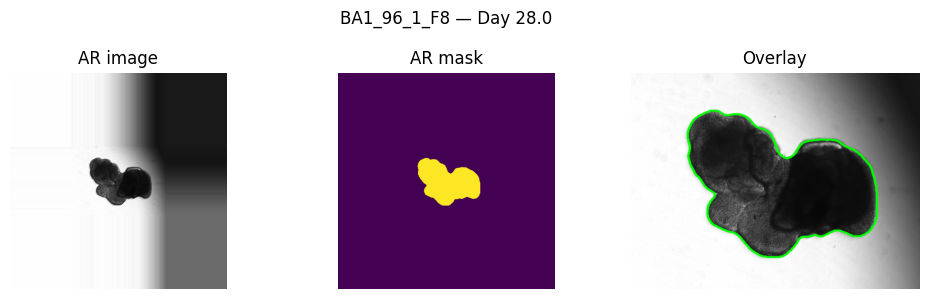

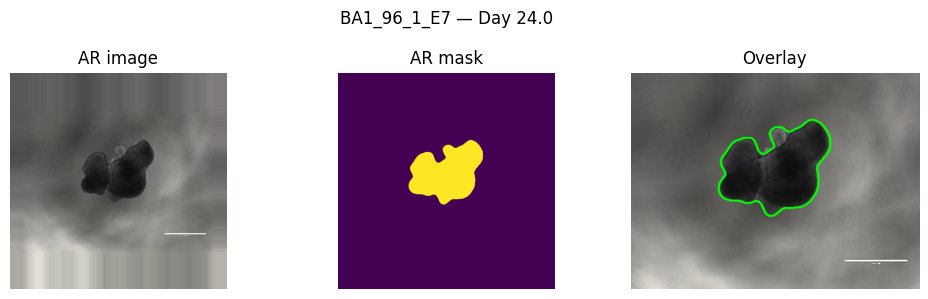

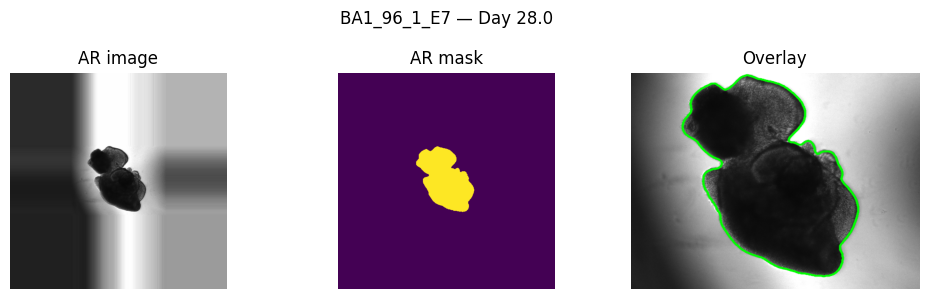

In [36]:
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image

TOP_IDS = [
    "BA1_96_1_A8",
    "BA1_96_1_H5",
    "BA1_96_1_F3",
    "BA1_96_1_F8",
    "BA1_96_1_E7",
]

def show_day(organoid_id, day):
    key = None
    
    # find matching entry in JSON
    for rid, entry in data.items():
        if entry.get("organoid_id") == organoid_id and entry.get("day", {}).get("number") == day:
            key = rid
            break
    
    if key is None:
        print(f"{organoid_id} day {day} not found")
        return
    
    entry = data[key]
    imgs = entry["images"]
    
    ar_img = Path(DATA_DIR / "images" / "resized_575_square" / imgs["aspect_ratio"]["ar_image"])
    ar_mask = Path(DATA_DIR / "masks" / "resized_575_square" / imgs["aspect_ratio"]["ar_mask"])
    overlay = Path(imgs["overlay_path"])
    
    fig, axes = plt.subplots(1,3, figsize=(10,3))
    fig.suptitle(f"{organoid_id} — Day {day}")
    
    axes[0].imshow(Image.open(ar_img))
    axes[0].set_title("AR image")
    axes[0].axis("off")
    
    axes[1].imshow(Image.open(ar_mask))
    axes[1].set_title("AR mask")
    axes[1].axis("off")
    
    if overlay.exists():
        axes[2].imshow(Image.open(overlay))
        axes[2].set_title("Overlay")
    else:
        axes[2].text(0.5,0.5,"No overlay", ha="center")
    
    axes[2].axis("off")
    plt.tight_layout()
    plt.show()


# compare 24 vs 28
for oid in TOP_IDS:
    show_day(oid, 24.0)
    show_day(oid, 28.0)



In [35]:
def count_outliers(df, batch="BA1 96_1"):
    sub = df[df["batch"] == batch].copy()

    out = []
    for day, g in sub.groupby("day"):
        q1 = g["area_um2"].quantile(0.25)
        q3 = g["area_um2"].quantile(0.75)
        iqr = q3 - q1
        upper = q3 + 1.5 * iqr

        n_out = (g["area_um2"] > upper).sum()

        out.append({
            "day": day,
            "n_total": len(g),
            "n_outliers": n_out,
            "pct_outliers": 100 * n_out / len(g),
            "upper_cutoff": upper
        })

    return pd.DataFrame(out).sort_values("day")

out_stats = count_outliers(df)
out_stats



,day,n_total,n_outliers,pct_outliers,upper_cutoff
0,3.0,96,4,4.166667,246928.500
1,6.0,96,5,5.208333,338276.250
2,8.0,95,3,3.157895,283520.250
3,10.0,94,1,1.063830,360267.750
4,13.0,94,1,1.063830,759881.250
5,15.0,94,7,7.446809,976374.000
6,17.0,94,6,6.382979,882727.875
7,20.5,94,10,10.638298,1101498.750
8,24.0,94,13,13.829787,2188447.875
9,28.0,94,6,6.382979,2042344.125
